> **Repository note: 02_train_sac_nominal_seed0_to_300k.ipynb**
>
> First session of **SAC Nominal seed 0** (CPU), in **Cell 6**. The Colab session ended after the **300K-step checkpoint** (model + replay buffer). Training was resumed in notebook 03.
> 
> Outputs are preserved from the original session; cells after Cell 6 are earlier templates.

# Robust Locomotion Under Dynamics Shift: PPO vs. SAC with Domain Randomization
## Reinforcement Learning Project — Part 2

This notebook implements the **final Part 1 project plan**.

### Experimental design
- Environment: `Hopper-v5` (Gymnasium / MuJoCo)
- Algorithms: **Stable-Baselines3 PPO and SAC**
- Training regimes: **nominal** and **domain randomized**
- Final budget: **500,000 environment steps per run**
- Final seeds: **0, 1, 2, 3, 4**
- Validation: every **25,000 steps**, 10 deterministic nominal episodes
- Robustness test: **5 × 5 mass/friction grid**, 10 deterministic episodes per cell
- Success: episode lasts 1,000 steps **and** torso moves at least 3 m forward
- Analysis: learning-curve AUC, steps to return 1,500, wall-clock time, IQM,
  95% bootstrap confidence intervals, OOD robustness, worst-cell return, and robustness ratio

The previous from-scratch PPO assignment is retained only as historical context. Both algorithms in this experiment use Stable-Baselines3 to reduce implementation differences.

> Start with `SMOKE_TEST = True`. Change it to `False` only after the notebook runs end-to-end.


## 0. Install and import dependencies


In [ ]:
!pip install -q "gymnasium[mujoco]>=1.0.0" "stable-baselines3>=2.3.0" "imageio[ffmpeg]" pandas matplotlib scipy

import os


import time, json, random, shutil, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gymnasium as gym
import torch
from stable_baselines3 import PPO, SAC
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.monitor import Monitor
import imageio.v2 as imageio

warnings.filterwarnings("ignore")

#RESULTS_DIR = "rl_part2_results"  --- Smoke teting directory
RESULTS_DIR = "rl_part2_final_results"

MODEL_DIR = os.path.join(RESULTS_DIR, "models")
CHECKPOINT_DIR = os.path.join(RESULTS_DIR, "checkpoints")
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

#print("MUJOCO_GL:", os.environ.get("MUJOCO_GL"))
#print("PYOPENGL_PLATFORM:", os.environ.get("PYOPENGL_PLATFORM"))

print("Gymnasium:", gym.__version__)
print("PyTorch:", torch.__version__)
print("SB3 PPO and SAC imported successfully.")

Gymnasium: 1.3.0
PyTorch: 2.11.0+cpu
SB3 PPO and SAC imported successfully.


In [ ]:
print("RESULTS_DIR:", RESULTS_DIR)
print("MODEL_DIR:", MODEL_DIR)
print("CHECKPOINT_DIR:", CHECKPOINT_DIR)

print("\nExisting final validation file:",
      os.path.exists(os.path.join(RESULTS_DIR, "validation_learning_curves.csv")))

print("Existing final training-times file:",
      os.path.exists(os.path.join(RESULTS_DIR, "training_times.csv")))

RESULTS_DIR: rl_part2_final_results
MODEL_DIR: rl_part2_final_results/models
CHECKPOINT_DIR: rl_part2_final_results/checkpoints

Existing final validation file: False
Existing final training-times file: False


## 1. Configuration — final Part 1 plan


In [ ]:
SMOKE_TEST = False

FINAL_SEEDS = [0, 1, 2]   # changed the seed 5 to seed 3
FINAL_TRAIN_STEPS = 500_000
FINAL_EVAL_EVERY = 25_000
FINAL_EVAL_EPISODES = 10
FINAL_GRID_EPISODES = 10

# Fast end-to-end test settings.
SEEDS = [0] if SMOKE_TEST else FINAL_SEEDS
TRAIN_STEPS = 20_000 if SMOKE_TEST else FINAL_TRAIN_STEPS
EVAL_EVERY = 5_000 if SMOKE_TEST else FINAL_EVAL_EVERY
EVAL_EPISODES = 3 if SMOKE_TEST else FINAL_EVAL_EPISODES
GRID_EPISODES = 2 if SMOKE_TEST else FINAL_GRID_EPISODES

MASS_SCALES = np.array([0.8, 1.0, 1.2]) if SMOKE_TEST else np.array([0.6, 0.8, 1.0, 1.2, 1.4])
FRICTION_SCALES = np.array([0.75, 1.0, 1.25]) if SMOKE_TEST else np.array([0.5, 0.75, 1.0, 1.25, 1.5])

TRAIN_MASS_RANGE = (0.8, 1.2)
TRAIN_FRICTION_RANGE = (0.7, 1.3)
THRESHOLD_RETURN = 1500
SUCCESS_DISTANCE = 3.0
MAX_EPISODE_STEPS = 1000

print("Mode:", "SMOKE TEST" if SMOKE_TEST else "FINAL")
print("Seeds:", SEEDS)
print("Steps/run:", TRAIN_STEPS)
print("Validation interval:", EVAL_EVERY)
print("Validation episodes:", EVAL_EPISODES)
print("Grid episodes/cell:", GRID_EPISODES)


Mode: FINAL
Seeds: [0, 1, 2]
Steps/run: 500000
Validation interval: 25000
Validation episodes: 10
Grid episodes/cell: 10


## 2. Hopper environment and domain randomization

At each randomized-training episode reset:
- all body masses are scaled by one factor sampled from `U[0.8, 1.2]`;
- contact-surface friction is scaled by one factor sampled from `U[0.7, 1.3]`.

The factors are applied relative to stored nominal MuJoCo parameters so they do not accumulate.  
The policy does **not** observe the sampled physics factors.


In [ ]:
class DynamicsShiftWrapper(gym.Wrapper):
    def __init__(self, env, randomize=False,
                 mass_range=TRAIN_MASS_RANGE,
                 friction_range=TRAIN_FRICTION_RANGE,
                 fixed_mass=None, fixed_friction=None):
        super().__init__(env)
        self.randomize = randomize
        self.mass_range = mass_range
        self.friction_range = friction_range
        self.fixed_mass = fixed_mass
        self.fixed_friction = fixed_friction

        model = self.env.unwrapped.model
        self.base_body_mass = model.body_mass.copy()
        self.base_geom_friction = model.geom_friction.copy()

    def _set_physics(self, mass_scale, friction_scale):
        model = self.env.unwrapped.model
        model.body_mass[:] = self.base_body_mass * float(mass_scale)
        model.geom_friction[:] = self.base_geom_friction * float(friction_scale)
        try:
            import mujoco
            mujoco.mj_setConst(model, self.env.unwrapped.data)
        except Exception:
            pass

    def reset(self, **kwargs):
        # Reset first so Gymnasium establishes RNG state.
        obs, info = self.env.reset(**kwargs)

        mass = (self.fixed_mass if self.fixed_mass is not None else
                self.np_random.uniform(*self.mass_range) if self.randomize else 1.0)
        friction = (self.fixed_friction if self.fixed_friction is not None else
                    self.np_random.uniform(*self.friction_range) if self.randomize else 1.0)

        self._set_physics(mass, friction)
        obs, info = self.env.reset()
        info = dict(info)
        info["mass_scale"] = float(mass)
        info["friction_scale"] = float(friction)
        return obs, info


def make_env(seed=0, randomize=False, fixed_mass=None, fixed_friction=None,
             render_mode=None):
    env = gym.make("Hopper-v5", render_mode=render_mode)
    env = DynamicsShiftWrapper(
        env,
        randomize=randomize,
        fixed_mass=fixed_mass,
        fixed_friction=fixed_friction
    )
    env.action_space.seed(seed)
    return env


# Sanity check
env = make_env(seed=0, randomize=True)
obs, info = env.reset(seed=0)
print("Observation:", obs.shape, "| Action:", env.action_space.shape)
print("Sample mass/friction:", info["mass_scale"], info["friction_scale"])
env.close()


Observation: (11,) | Action: (3,)
Sample mass/friction: 1.1429617106350278 0.7201513451832786


## 3. Deterministic evaluation used for both algorithms


In [ ]:
def deterministic_evaluate(model, mass=1.0, friction=1.0, n_episodes=10, seed=10000,
                           capture_video=False):
    env = make_env(seed=seed, fixed_mass=mass, fixed_friction=friction,
                   render_mode="rgb_array" if capture_video else None)
    rows, frames = [], []

    for ep in range(n_episodes):
        obs, _ = env.reset(seed=seed + ep)

        # Hopper x position is excluded from the observation, so read it from MuJoCo qpos.
        start_x = float(env.unwrapped.data.qpos[0])
        total_return = 0.0
        length = 0
        done = False

        while not done:
            if capture_video and ep == 0:
                frames.append(env.render())

            action, _ = model.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, _ = env.step(action)
            total_return += float(reward)
            length += 1
            done = terminated or truncated

        end_x = float(env.unwrapped.data.qpos[0])
        distance = end_x - start_x
        success = int(length >= MAX_EPISODE_STEPS and distance >= SUCCESS_DISTANCE)

        rows.append({
            "episode": ep,
            "return": total_return,
            "length": length,
            "distance_m": distance,
            "success": success
        })

    env.close()
    return pd.DataFrame(rows), frames


## 4. Validation + checkpoint callback

The final Part 1 plan evaluates each agent every **25,000 environment steps** using
10 deterministic episodes on the **nominal** environment and separate evaluation seeds.

The callback also saves checkpoints every **100,000 steps** in final mode.


In [ ]:
class ProjectEvalCallback(BaseCallback):
    def __init__(self, algorithm, regime, seed, eval_every, eval_episodes,
                 checkpoint_every=100_000):
        super().__init__()
        self.algorithm = algorithm
        self.regime = regime
        self.seed_value = seed
        self.eval_every = eval_every
        self.eval_episodes = eval_episodes
        self.checkpoint_every = checkpoint_every
        self.next_eval = eval_every
        self.next_checkpoint = checkpoint_every
        self.rows = []

    def _on_step(self):
        if self.num_timesteps >= self.next_eval:
            df, _ = deterministic_evaluate(
                self.model, mass=1.0, friction=1.0,
                n_episodes=self.eval_episodes,
                seed=20_000 + self.seed_value * 100
            )
            self.rows.append({
                "algorithm": self.algorithm,
                "regime": self.regime,
                "seed": self.seed_value,
                "step": self.num_timesteps,
                "mean_return": df["return"].mean(),
                "success_rate": df["success"].mean(),
                "mean_distance_m": df["distance_m"].mean()
            })
            print(f"{self.algorithm:3s} | {self.regime:10s} | seed {self.seed_value} | "
                  f"step {self.num_timesteps:6d} | return {df['return'].mean():8.1f}")
            self.next_eval += self.eval_every

        if self.num_timesteps >= self.next_checkpoint:
            name = f"{self.algorithm.lower()}_{self.regime}_seed{self.seed_value}_{self.num_timesteps}"
            self.model.save(os.path.join(CHECKPOINT_DIR, name))
            self.next_checkpoint += self.checkpoint_every

        return True


## 5. Stable-Baselines3 PPO and SAC

Final Part 1 settings:
- **PPO:** 2×256 tanh network, learning rate `3e-4`, γ=.99, 2,048 rollout steps,
  10 epochs, minibatch 64, clip=.2, GAE λ=.95, entropy coefficient 0.
- **SAC:** 2×256 ReLU network, learning rate `3e-4`, γ=.99, replay buffer 1,000,000,
  batch 256, τ=.005, automatic entropy tuning, 10,000 initial random steps.


In [ ]:
def build_model(algorithm, env, seed):
    if algorithm == "PPO":
        return PPO(
            "MlpPolicy", env,
            learning_rate=3e-4,
            n_steps=2048,
            batch_size=64,
            n_epochs=10,
            gamma=0.99,
            gae_lambda=0.95,
            clip_range=0.2,
            ent_coef=0.0,
            policy_kwargs=dict(
                net_arch=dict(pi=[256, 256], vf=[256, 256]),
                activation_fn=torch.nn.Tanh
            ),
            seed=seed,
            verbose=0,
            device="auto"
        )

    if algorithm == "SAC":
        return SAC(
            "MlpPolicy", env,
            learning_rate=3e-4,
            buffer_size=1_000_000,
            learning_starts=10_000 if not SMOKE_TEST else 1_000,
            batch_size=256,
            tau=0.005,
            gamma=0.99,
            train_freq=1,
            gradient_steps=1,
            ent_coef="auto",
            policy_kwargs=dict(
                net_arch=dict(pi=[256, 256], qf=[256, 256]),
                activation_fn=torch.nn.ReLU
            ),
            seed=seed,
            verbose=0,
            device="auto"
        )

    raise ValueError("algorithm must be PPO or SAC")


In [ ]:
print(os.path.exists("/content/drive/MyDrive"))

True


## 6. Train the four experimental conditions


In [ ]:
# ============================================================
# CELL 6 — SAFE SAC FINAL TRAINING WITH GOOGLE DRIVE CHECKPOINTS
# ============================================================

import os
import time
import pandas as pd

from stable_baselines3.common.callbacks import (
    CallbackList,
    CheckpointCallback
)

# ------------------------------------------------------------
# 1. GOOGLE DRIVE FINAL RESULTS DIRECTORY
# ------------------------------------------------------------

RESULTS_DIR = "/content/drive/MyDrive/RL_Part2/rl_part2_final_results"

MODEL_DIR = os.path.join(RESULTS_DIR, "models")
CHECKPOINT_DIR = os.path.join(RESULTS_DIR, "checkpoints")

os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

print("RESULTS_DIR:", RESULTS_DIR)
print("MODEL_DIR:", MODEL_DIR)
print("CHECKPOINT_DIR:", CHECKPOINT_DIR)


# ------------------------------------------------------------
# 2. SELECT ONLY ONE SAC RUN AT A TIME
# ------------------------------------------------------------

RUN_ALGORITHMS = ["SAC"]
RUN_REGIMES = ["nominal"]
RUN_SEEDS = [0]

# Later we will change ONLY the settings above for:
#
# SAC nominal seed 1
# SAC nominal seed 2
# SAC randomized seed 0
# SAC randomized seed 1
# SAC randomized seed 2


# ------------------------------------------------------------
# 3. LOAD EXISTING PPO/SAC RESULTS FROM GOOGLE DRIVE
# ------------------------------------------------------------

validation_csv = os.path.join(
    RESULTS_DIR,
    "validation_learning_curves.csv"
)

training_times_csv = os.path.join(
    RESULTS_DIR,
    "training_times.csv"
)

if os.path.exists(validation_csv):
    validation_df = pd.read_csv(validation_csv)
    validation_rows = validation_df.to_dict("records")
    print(f"\nLoaded {len(validation_df)} existing validation rows.")
else:
    validation_rows = []
    print("\nNo existing validation CSV found.")

if os.path.exists(training_times_csv):
    training_times_df = pd.read_csv(training_times_csv)
    training_time_rows = training_times_df.to_dict("records")
    print(f"Loaded {len(training_times_df)} existing training records.")
else:
    training_time_rows = []
    print("No existing training-times CSV found.")


# ------------------------------------------------------------
# 4. BUILD LIST OF SELECTED RUNS
# ------------------------------------------------------------

selected_runs = [
    (algorithm, regime, seed)
    for algorithm in RUN_ALGORITHMS
    for regime in RUN_REGIMES
    for seed in RUN_SEEDS
]

print("\nSelected training runs:")

for r in selected_runs:
    print("   ", r)

print(f"\nNumber of runs in this session: {len(selected_runs)}")


# ------------------------------------------------------------
# 5. TRAIN SELECTED SAC RUN
# ------------------------------------------------------------

trained = {}

for run_number, (algorithm, regime, seed) in enumerate(
    selected_runs,
    start=1
):

    print("\n" + "=" * 72)
    print(
        f"RUN {run_number}/{len(selected_runs)}: "
        f"{algorithm} | {regime} | seed {seed}"
    )
    print("=" * 72)

    # --------------------------------------------------------
    # Check whether this FINAL run already completed
    # --------------------------------------------------------

    already_completed = any(
        str(row["algorithm"]).upper() == algorithm.upper()
        and str(row["regime"]).lower() == regime.lower()
        and int(row["seed"]) == seed
        for row in training_time_rows
    )

    if already_completed:
        print(
            "SKIPPING — this run already exists "
            "in training_times.csv"
        )
        continue


    # --------------------------------------------------------
    # Create environment and model
    # --------------------------------------------------------

    randomize = regime == "randomized"

    env = Monitor(
        make_env(
            seed=seed,
            randomize=randomize
        )
    )

    model = build_model(
        algorithm,
        env,
        seed
    )


    # --------------------------------------------------------
    # Existing evaluation callback
    # --------------------------------------------------------

    eval_callback = ProjectEvalCallback(
        algorithm=algorithm,
        regime=regime,
        seed=seed,
        eval_every=EVAL_EVERY,
        eval_episodes=EVAL_EPISODES
    )


    # --------------------------------------------------------
    # NEW: checkpoint every 100,000 steps
    # --------------------------------------------------------

    checkpoint_prefix = (
        f"{algorithm.lower()}_{regime}_seed{seed}"
    )

    checkpoint_callback = CheckpointCallback(
        save_freq=100_000,
        save_path=CHECKPOINT_DIR,
        name_prefix=checkpoint_prefix,

        # Important for SAC because SAC uses a replay buffer
        save_replay_buffer=(algorithm.upper() == "SAC"),

        verbose=1
    )


    # Run evaluation + checkpoint callbacks together
    callbacks = CallbackList([
        eval_callback,
        checkpoint_callback
    ])


    # --------------------------------------------------------
    # Train
    # --------------------------------------------------------

    print(
        f"\nStarting {algorithm} | {regime} | "
        f"seed {seed}"
    )

    print(
        f"Training steps: {TRAIN_STEPS:,}"
    )

    print(
        "Checkpoint interval: 100,000 steps"
    )

    start = time.time()

    model.learn(
        total_timesteps=TRAIN_STEPS,
        callback=callbacks,
        progress_bar=False
    )

    elapsed = time.time() - start


    # --------------------------------------------------------
    # Save final model directly to Google Drive
    # --------------------------------------------------------

    model_path = os.path.join(
        MODEL_DIR,
        f"{algorithm.lower()}_{regime}_seed{seed}"
    )

    model.save(model_path)

    print(
        f"\nSaved final model: {model_path}.zip"
    )


    # --------------------------------------------------------
    # Save final replay buffer for SAC
    # --------------------------------------------------------

    if algorithm.upper() == "SAC":

        replay_buffer_path = os.path.join(
            CHECKPOINT_DIR,
            f"{algorithm.lower()}_{regime}_seed{seed}"
            "_final_replay_buffer.pkl"
        )

        model.save_replay_buffer(
            replay_buffer_path
        )

        print(
            "Saved final SAC replay buffer:",
            replay_buffer_path
        )


    # --------------------------------------------------------
    # Save validation results immediately
    # --------------------------------------------------------

    trained[(algorithm, regime, seed)] = model

    validation_rows.extend(
        eval_callback.rows
    )

    validation_df = pd.DataFrame(
        validation_rows
    )

    validation_df.to_csv(
        validation_csv,
        index=False
    )


    # --------------------------------------------------------
    # Save training-time record immediately
    # --------------------------------------------------------

    training_time_rows.append({
        "algorithm": algorithm,
        "regime": regime,
        "seed": seed,
        "wall_clock_seconds": elapsed,
        "wall_clock_hours": elapsed / 3600
    })

    training_times_df = pd.DataFrame(
        training_time_rows
    )

    training_times_df.to_csv(
        training_times_csv,
        index=False
    )


    env.close()


    # --------------------------------------------------------
    # Completion message
    # --------------------------------------------------------

    print("\n" + "-" * 72)

    print(
        f"COMPLETED: {algorithm} | "
        f"{regime} | seed {seed}"
    )

    print(
        f"Training time: "
        f"{elapsed / 3600:.2f} hours"
    )

    print(
        "Final model, replay buffer, "
        "validation results and training-time "
        "CSV saved to Google Drive."
    )

    print("-" * 72)


# ------------------------------------------------------------
# 6. SESSION SUMMARY
# ------------------------------------------------------------

training_times_df = pd.DataFrame(
    training_time_rows
)

print("\n" + "=" * 72)
print("THIS TRAINING SESSION IS COMPLETE")
print("=" * 72)

display(
    training_times_df.round(3)
)

RESULTS_DIR: /content/drive/MyDrive/RL_Part2/rl_part2_final_results
MODEL_DIR: /content/drive/MyDrive/RL_Part2/rl_part2_final_results/models
CHECKPOINT_DIR: /content/drive/MyDrive/RL_Part2/rl_part2_final_results/checkpoints

Loaded 120 existing validation rows.
Loaded 6 existing training records.

Selected training runs:
    ('SAC', 'nominal', 0)

Number of runs in this session: 1

RUN 1/1: SAC | nominal | seed 0

Starting SAC | nominal | seed 0
Training steps: 500,000
Checkpoint interval: 100,000 steps
SAC | nominal    | seed 0 | step  25000 | return    299.7
SAC | nominal    | seed 0 | step  50000 | return    332.2
SAC | nominal    | seed 0 | step  75000 | return    428.4
SAC | nominal    | seed 0 | step 100000 | return    459.5
SAC | nominal    | seed 0 | step 125000 | return    405.8
SAC | nominal    | seed 0 | step 150000 | return   1622.4
SAC | nominal    | seed 0 | step 175000 | return   1069.6
SAC | nominal    | seed 0 | step 200000 | return   2431.6
SAC | nominal    | seed 0 |

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
import shutil

DRIVE_BACKUP_DIR = "/content/drive/MyDrive/RL_Part2/rl_part2_final_results"

os.makedirs("/content/drive/MyDrive/RL_Part2", exist_ok=True)

shutil.copytree(
    RESULTS_DIR,
    DRIVE_BACKUP_DIR,
    dirs_exist_ok=True
)

print("PPO results backed up successfully.")
print("Backup location:", DRIVE_BACKUP_DIR)

print("\nFiles in backup:")
for root, dirs, files in os.walk(DRIVE_BACKUP_DIR):
    for file in files:
        print(os.path.join(root, file))

Mounted at /content/drive
PPO results backed up successfully.
Backup location: /content/drive/MyDrive/RL_Part2/rl_part2_final_results

Files in backup:
/content/drive/MyDrive/RL_Part2/rl_part2_final_results/training_times.csv
/content/drive/MyDrive/RL_Part2/rl_part2_final_results/validation_learning_curves.csv
/content/drive/MyDrive/RL_Part2/rl_part2_final_results/models/ppo_randomized_seed0.zip
/content/drive/MyDrive/RL_Part2/rl_part2_final_results/models/ppo_nominal_seed1.zip
/content/drive/MyDrive/RL_Part2/rl_part2_final_results/models/ppo_randomized_seed1.zip
/content/drive/MyDrive/RL_Part2/rl_part2_final_results/models/ppo_nominal_seed0.zip
/content/drive/MyDrive/RL_Part2/rl_part2_final_results/models/ppo_nominal_seed2.zip
/content/drive/MyDrive/RL_Part2/rl_part2_final_results/models/ppo_randomized_seed2.zip
/content/drive/MyDrive/RL_Part2/rl_part2_final_results/checkpoints/ppo_nominal_seed0_500000.zip
/content/drive/MyDrive/RL_Part2/rl_part2_final_results/checkpoints/ppo_nominal_

## 7. Learning curves, AUC, and steps to return 1,500


,algorithm,regime,seed,learning_curve_auc,steps_to_1500,wall_clock_seconds,wall_clock_hours
0,PPO,nominal,0,2071868.16,20000,43.64,0.01
1,PPO,randomized,0,2452020.82,20000,43.45,0.01
2,SAC,nominal,0,3987956.71,20000,492.18,0.14
3,SAC,randomized,0,5003951.02,20000,492.84,0.14


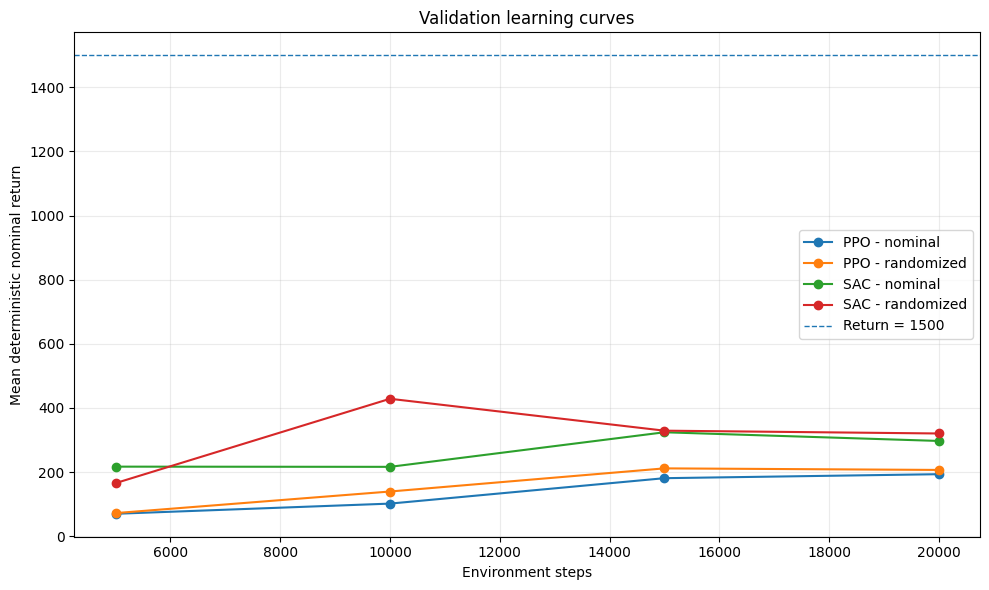

In [ ]:
def trapezoid_auc(g):
    g = g.sort_values("step")
    if len(g) < 2:
        return np.nan
    return np.trapz(g["mean_return"].to_numpy(), g["step"].to_numpy())

efficiency_rows = []
for (algorithm, regime, seed), g in validation_df.groupby(["algorithm", "regime", "seed"]):
    g = g.sort_values("step")
    hits = g[g["mean_return"] >= THRESHOLD_RETURN]
    steps_to = int(hits.iloc[0]["step"]) if len(hits) else TRAIN_STEPS
    efficiency_rows.append({
        "algorithm": algorithm,
        "regime": regime,
        "seed": seed,
        "learning_curve_auc": trapezoid_auc(g),
        "steps_to_1500": steps_to
    })

efficiency_df = pd.DataFrame(efficiency_rows).merge(
    training_times_df, on=["algorithm", "regime", "seed"], how="left"
)
efficiency_df.to_csv(os.path.join(RESULTS_DIR, "training_efficiency.csv"), index=False)
display(efficiency_df.round(2))

plt.figure(figsize=(10, 6))
for (algorithm, regime), g in validation_df.groupby(["algorithm", "regime"]):
    curve = g.groupby("step")["mean_return"].mean()
    plt.plot(curve.index, curve.values, marker="o", label=f"{algorithm} - {regime}")
plt.axhline(THRESHOLD_RETURN, linestyle="--", linewidth=1, label="Return = 1500")
plt.xlabel("Environment steps")
plt.ylabel("Mean deterministic nominal return")
plt.title("Validation learning curves")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "learning_curves.png"), dpi=180)
plt.show()


## 8. Final 5×5 mass/friction robustness test


In [ ]:
grid_rows = []
total = len(trained) * len(MASS_SCALES) * len(FRICTION_SCALES)
counter = 0

for (algorithm, regime, seed), model in trained.items():
    for mass in MASS_SCALES:
        for friction in FRICTION_SCALES:
            counter += 1
            print(f"[{counter}/{total}] {algorithm} {regime} seed={seed} "
                  f"mass={mass:.2f} friction={friction:.2f}")

            df, _ = deterministic_evaluate(
                model,
                mass=float(mass),
                friction=float(friction),
                n_episodes=GRID_EPISODES,
                seed=40_000 + seed * 100
            )

            in_distribution = (
                TRAIN_MASS_RANGE[0] <= mass <= TRAIN_MASS_RANGE[1] and
                TRAIN_FRICTION_RANGE[0] <= friction <= TRAIN_FRICTION_RANGE[1]
            )

            grid_rows.append({
                "algorithm": algorithm,
                "regime": regime,
                "seed": seed,
                "mass_scale": float(mass),
                "friction_scale": float(friction),
                "distribution": "ID" if in_distribution else "OOD",
                "mean_return": df["return"].mean(),
                "mean_distance_m": df["distance_m"].mean(),
                "success_rate": df["success"].mean(),
                "mean_length": df["length"].mean()
            })

grid_df = pd.DataFrame(grid_rows)
grid_df.to_csv(os.path.join(RESULTS_DIR, "robustness_grid.csv"), index=False)
display(grid_df.head())


[1/36] PPO nominal seed=0 mass=0.80 friction=0.75
[2/36] PPO nominal seed=0 mass=0.80 friction=1.00
[3/36] PPO nominal seed=0 mass=0.80 friction=1.25
[4/36] PPO nominal seed=0 mass=1.00 friction=0.75
[5/36] PPO nominal seed=0 mass=1.00 friction=1.00
[6/36] PPO nominal seed=0 mass=1.00 friction=1.25
[7/36] PPO nominal seed=0 mass=1.20 friction=0.75
[8/36] PPO nominal seed=0 mass=1.20 friction=1.00
[9/36] PPO nominal seed=0 mass=1.20 friction=1.25
[10/36] PPO randomized seed=0 mass=0.80 friction=0.75
[11/36] PPO randomized seed=0 mass=0.80 friction=1.00
[12/36] PPO randomized seed=0 mass=0.80 friction=1.25
[13/36] PPO randomized seed=0 mass=1.00 friction=0.75
[14/36] PPO randomized seed=0 mass=1.00 friction=1.00
[15/36] PPO randomized seed=0 mass=1.00 friction=1.25
[16/36] PPO randomized seed=0 mass=1.20 friction=0.75
[17/36] PPO randomized seed=0 mass=1.20 friction=1.00
[18/36] PPO randomized seed=0 mass=1.20 friction=1.25
[19/36] SAC nominal seed=0 mass=0.80 friction=0.75
[20/36] SAC n

,algorithm,regime,seed,mass_scale,friction_scale,distribution,mean_return,mean_distance_m,success_rate,mean_length
0,PPO,nominal,0,0.8,0.75,ID,252.046233,1.076447,0.0,118.5
1,PPO,nominal,0,0.8,1.00,ID,256.735993,1.101974,0.0,120.0
2,PPO,nominal,0,0.8,1.25,ID,259.166946,1.105432,0.0,122.0
3,PPO,nominal,0,1.0,0.75,ID,242.646753,1.021254,0.0,116.0
4,PPO,nominal,0,1.0,1.00,ID,250.057627,1.060548,0.0,118.5


## 9. Robustness heatmaps


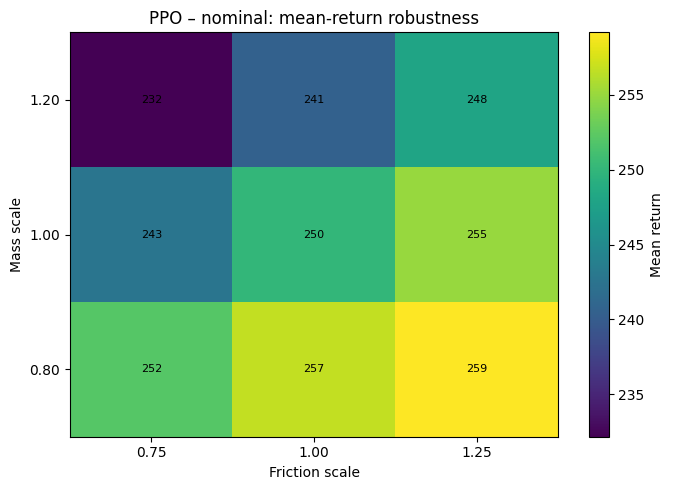

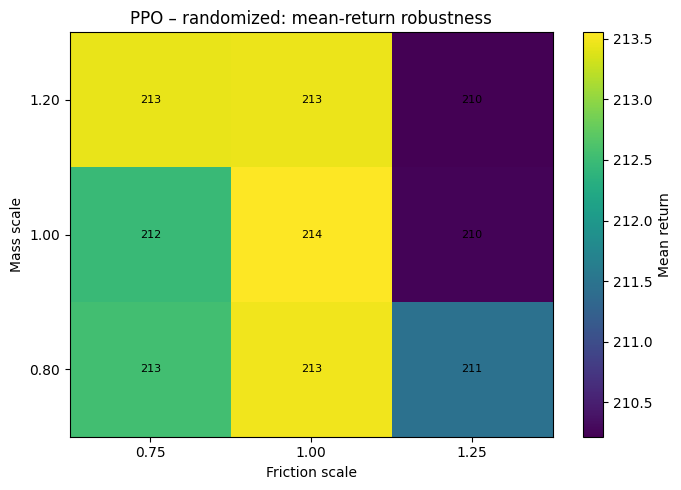

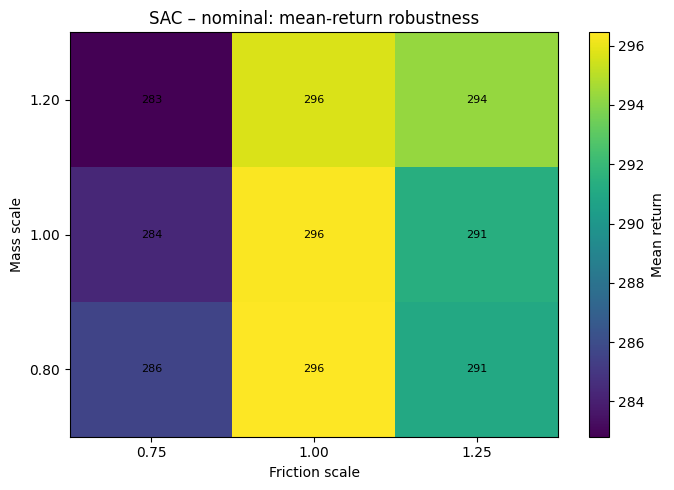

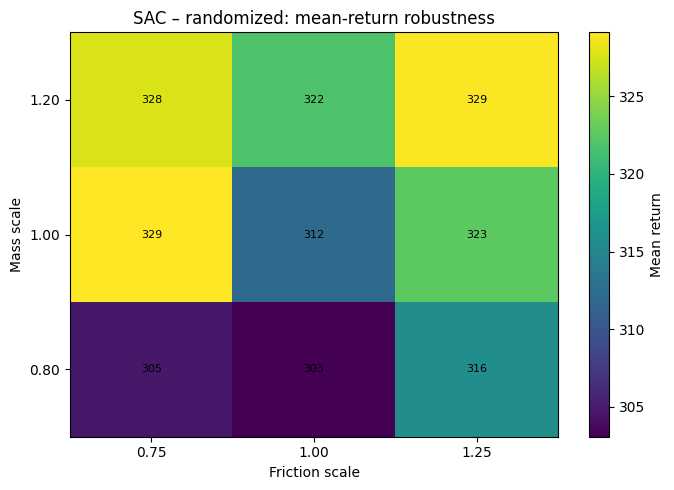

In [ ]:
for (algorithm, regime), g in grid_df.groupby(["algorithm", "regime"]):
    pivot = g.groupby(["mass_scale", "friction_scale"])["mean_return"].mean().unstack()

    plt.figure(figsize=(7, 5))
    im = plt.imshow(pivot.values, origin="lower", aspect="auto")
    plt.colorbar(im, label="Mean return")
    plt.xticks(range(len(pivot.columns)), [f"{x:.2f}" for x in pivot.columns])
    plt.yticks(range(len(pivot.index)), [f"{x:.2f}" for x in pivot.index])
    plt.xlabel("Friction scale")
    plt.ylabel("Mass scale")
    plt.title(f"{algorithm} – {regime}: mean-return robustness")

    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            plt.text(j, i, f"{pivot.iloc[i,j]:.0f}",
                     ha="center", va="center", fontsize=8)

    plt.tight_layout()
    plt.savefig(os.path.join(
        RESULTS_DIR, f"heatmap_{algorithm.lower()}_{regime}.png"), dpi=180)
    plt.show()


## 10. IQM and 95% bootstrap confidence intervals

Part 1 specifies interquartile means (IQM) across seeds and bootstrap confidence intervals.

For five final seeds, the function below:
1. sorts the seed-level values;
2. computes a 25%-trimmed mean using fractional boundary weights;
3. bootstraps the seed-level observations to estimate a 95% confidence interval.

With only five seeds, confidence intervals can be wide; this limitation should be acknowledged in Part 2.


In [ ]:
def iqm(values):
    x = np.sort(np.asarray(values, dtype=float))
    n = len(x)
    if n == 0:
        return np.nan
    # Mean of the empirical quantile function from 25% to 75%.
    lo, hi = 0.25*n, 0.75*n
    total = 0.0
    weight = 0.0
    for i, value in enumerate(x):
        left, right = i, i+1
        overlap = max(0.0, min(right, hi) - max(left, lo))
        total += overlap * value
        weight += overlap
    return total / weight if weight else np.nan


def bootstrap_iqm_ci(values, n_boot=5000, seed=123):
    x = np.asarray(values, dtype=float)
    rng = np.random.default_rng(seed)
    boots = np.array([iqm(rng.choice(x, size=len(x), replace=True))
                      for _ in range(n_boot)])
    return iqm(x), np.percentile(boots, 2.5), np.percentile(boots, 97.5)


def bootstrap_difference_ci(a, b, n_boot=5000, seed=456):
    a, b = np.asarray(a, float), np.asarray(b, float)
    rng = np.random.default_rng(seed)
    diffs = []
    for _ in range(n_boot):
        aa = rng.choice(a, size=len(a), replace=True)
        bb = rng.choice(b, size=len(b), replace=True)
        diffs.append(iqm(aa) - iqm(bb))
    return iqm(a)-iqm(b), *np.percentile(diffs, [2.5, 97.5])


## 11. Seed-level final metrics


In [ ]:
seed_metrics = []

for (algorithm, regime, seed), g in grid_df.groupby(["algorithm", "regime", "seed"]):
    nominal = g[(g.mass_scale == 1.0) & (g.friction_scale == 1.0)]
    ood = g[g.distribution == "OOD"]

    # In smoke mode the reduced grid may contain no OOD cells.
    if len(ood) == 0:
        ood = g[(g.mass_scale != 1.0) | (g.friction_scale != 1.0)]

    nominal_return = nominal["mean_return"].iloc[0]
    ood_mean = ood["mean_return"].mean()

    seed_metrics.append({
        "algorithm": algorithm,
        "regime": regime,
        "seed": seed,
        "nominal_return": nominal_return,
        "nominal_success_rate": nominal["success_rate"].iloc[0],
        "ood_mean_return": ood_mean,
        "ood_success_rate": ood["success_rate"].mean(),
        "worst_cell_return": g["mean_return"].min(),
        "robustness_ratio": ood_mean / nominal_return if nominal_return != 0 else np.nan,
        "final_nominal_iqr_input": nominal_return
    })

seed_metrics_df = pd.DataFrame(seed_metrics)
seed_metrics_df.to_csv(os.path.join(RESULTS_DIR, "seed_level_metrics.csv"), index=False)
display(seed_metrics_df.round(3))


,algorithm,regime,seed,nominal_return,nominal_success_rate,ood_mean_return,ood_success_rate,worst_cell_return,robustness_ratio,final_nominal_iqr_input
0,PPO,nominal,0,250.058,0.0,248.283,0.0,232.167,0.993,250.058
1,PPO,randomized,0,213.551,0.0,212.166,0.0,210.218,0.994,213.551
2,SAC,nominal,0,296.364,0.0,290.196,0.0,282.807,0.979,296.364
3,SAC,randomized,0,312.058,0.0,319.242,0.0,303.066,1.023,312.058


## 12. Aggregate metrics and 95% bootstrap CIs


In [ ]:
summary_rows = []

metrics = [
    "nominal_return", "nominal_success_rate", "ood_mean_return",
    "ood_success_rate", "worst_cell_return", "robustness_ratio"
]

for (algorithm, regime), g in seed_metrics_df.groupby(["algorithm", "regime"]):
    row = {"algorithm": algorithm, "regime": regime}
    for metric in metrics:
        center, low, high = bootstrap_iqm_ci(g[metric].dropna().values)
        row[f"{metric}_iqm"] = center
        row[f"{metric}_ci_low"] = low
        row[f"{metric}_ci_high"] = high

    row["nominal_return_iqr"] = (
        g["nominal_return"].quantile(0.75) - g["nominal_return"].quantile(0.25)
    )
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(os.path.join(RESULTS_DIR, "summary_iqm_ci.csv"), index=False)
display(summary_df.round(3))


,algorithm,regime,nominal_return_iqm,nominal_return_ci_low,nominal_return_ci_high,nominal_success_rate_iqm,nominal_success_rate_ci_low,nominal_success_rate_ci_high,ood_mean_return_iqm,ood_mean_return_ci_low,...,ood_success_rate_iqm,ood_success_rate_ci_low,ood_success_rate_ci_high,worst_cell_return_iqm,worst_cell_return_ci_low,worst_cell_return_ci_high,robustness_ratio_iqm,robustness_ratio_ci_low,robustness_ratio_ci_high,nominal_return_iqr
0,PPO,nominal,250.058,250.058,250.058,0.0,0.0,0.0,248.283,248.283,...,0.0,0.0,0.0,232.167,232.167,232.167,0.993,0.993,0.993,0.0
1,PPO,randomized,213.551,213.551,213.551,0.0,0.0,0.0,212.166,212.166,...,0.0,0.0,0.0,210.218,210.218,210.218,0.994,0.994,0.994,0.0
2,SAC,nominal,296.364,296.364,296.364,0.0,0.0,0.0,290.196,290.196,...,0.0,0.0,0.0,282.807,282.807,282.807,0.979,0.979,0.979,0.0
3,SAC,randomized,312.058,312.058,312.058,0.0,0.0,0.0,319.242,319.242,...,0.0,0.0,0.0,303.066,303.066,303.066,1.023,1.023,1.023,0.0


## 13. H1–H3 hypothesis analysis

The code reports the evidence; it does **not** force any hypothesis to be supported.

### H1 — Sample efficiency
Under nominal training, SAC is expected to have:
- larger learning-curve AUC than PPO;
- fewer steps to reach return 1,500.

### H2 — Brittleness
Nominally trained policies are expected to have:
- robustness ratio < 0.70;
- lower OOD success than nominal success.

### H3 — Domain randomization
For each algorithm, randomized training is expected to:
- increase robustness ratio;
- increase OOD success;
- lose less than 10% nominal return.


In [ ]:
hypothesis_rows = []

# H1: nominal SAC - nominal PPO for AUC; PPO - SAC for steps (positive means SAC is faster).
nom_eff = efficiency_df[efficiency_df.regime == "nominal"]
if set(nom_eff.algorithm.unique()) >= {"PPO", "SAC"}:
    ppo_auc = nom_eff[nom_eff.algorithm=="PPO"]["learning_curve_auc"].values
    sac_auc = nom_eff[nom_eff.algorithm=="SAC"]["learning_curve_auc"].values
    auc_diff = bootstrap_difference_ci(sac_auc, ppo_auc)

    ppo_steps = nom_eff[nom_eff.algorithm=="PPO"]["steps_to_1500"].values
    sac_steps = nom_eff[nom_eff.algorithm=="SAC"]["steps_to_1500"].values
    steps_diff = bootstrap_difference_ci(ppo_steps, sac_steps)

    hypothesis_rows.append({
        "hypothesis":"H1",
        "comparison":"SAC AUC - PPO AUC",
        "difference":auc_diff[0], "ci_low":auc_diff[1], "ci_high":auc_diff[2]
    })
    hypothesis_rows.append({
        "hypothesis":"H1",
        "comparison":"PPO steps_to_1500 - SAC steps_to_1500",
        "difference":steps_diff[0], "ci_low":steps_diff[1], "ci_high":steps_diff[2]
    })

# H2 descriptive checks for nominal policies.
for algorithm in ["PPO", "SAC"]:
    g = seed_metrics_df[(seed_metrics_df.algorithm==algorithm) &
                        (seed_metrics_df.regime=="nominal")]
    if len(g):
        hypothesis_rows.append({
            "hypothesis":"H2",
            "comparison":f"{algorithm} nominal robustness ratio",
            "difference":iqm(g.robustness_ratio),
            "ci_low":bootstrap_iqm_ci(g.robustness_ratio)[1],
            "ci_high":bootstrap_iqm_ci(g.robustness_ratio)[2]
        })

# H3 randomized - nominal differences.
for algorithm in ["PPO", "SAC"]:
    rand = seed_metrics_df[(seed_metrics_df.algorithm==algorithm) &
                           (seed_metrics_df.regime=="randomized")]
    nom = seed_metrics_df[(seed_metrics_df.algorithm==algorithm) &
                          (seed_metrics_df.regime=="nominal")]
    if len(rand) and len(nom):
        for metric in ["robustness_ratio", "ood_success_rate"]:
            d = bootstrap_difference_ci(rand[metric].values, nom[metric].values)
            hypothesis_rows.append({
                "hypothesis":"H3",
                "comparison":f"{algorithm} randomized - nominal {metric}",
                "difference":d[0], "ci_low":d[1], "ci_high":d[2]
            })

        nominal_loss = 1 - iqm(rand.nominal_return) / iqm(nom.nominal_return)
        hypothesis_rows.append({
            "hypothesis":"H3",
            "comparison":f"{algorithm} nominal-return fractional loss from randomization",
            "difference":nominal_loss, "ci_low":np.nan, "ci_high":np.nan
        })

hypothesis_df = pd.DataFrame(hypothesis_rows)
hypothesis_df.to_csv(os.path.join(RESULTS_DIR, "hypothesis_tests.csv"), index=False)
display(hypothesis_df.round(4))

print("\nInterpretation reminders:")
print("H1: CI excluding zero in the predicted direction supports the corresponding comparison.")
print("H2: compare nominal robustness-ratio IQM with the pre-specified 0.70 threshold.")
print("H3: positive robustness/success differences plus <10% nominal loss support the prediction.")


,hypothesis,comparison,difference,ci_low,ci_high
0,H1,SAC AUC - PPO AUC,1.916089e+06,1.916089e+06,1.916089e+06
1,H1,PPO steps_to_1500 - SAC steps_to_1500,0.000000e+00,0.000000e+00,0.000000e+00
2,H2,PPO nominal robustness ratio,9.929000e-01,9.929000e-01,9.929000e-01
3,H2,SAC nominal robustness ratio,9.792000e-01,9.792000e-01,9.792000e-01
4,H3,PPO randomized - nominal robustness_ratio,6.000000e-04,6.000000e-04,6.000000e-04
5,H3,PPO randomized - nominal ood_success_rate,0.000000e+00,0.000000e+00,0.000000e+00
6,H3,PPO nominal-return fractional loss from random...,1.460000e-01,NaN,NaN
7,H3,SAC randomized - nominal robustness_ratio,4.380000e-02,4.380000e-02,4.380000e-02
8,H3,SAC randomized - nominal ood_success_rate,0.000000e+00,0.000000e+00,0.000000e+00
9,H3,SAC nominal-return fractional loss from random...,-5.300000e-02,NaN,NaN



Interpretation reminders:
H1: CI excluding zero in the predicted direction supports the corresponding comparison.
H2: compare nominal robustness-ratio IQM with the pre-specified 0.70 threshold.
H3: positive robustness/success differences plus <10% nominal loss support the prediction.


## 14. Final project success criteria


In [ ]:
# Part 1 success criteria:
# (a) all four conditions grid-tested with at least 3 seeds;
# (b) each nominally trained algorithm has IQM nominal return >=1500
#     and nominal success rate >=80%.

criteria_rows = []
for algorithm in ["PPO", "SAC"]:
    g = seed_metrics_df[(seed_metrics_df.algorithm==algorithm) &
                        (seed_metrics_df.regime=="nominal")]
    if len(g):
        criteria_rows.append({
            "algorithm": algorithm,
            "number_of_seeds": len(g),
            "nominal_return_iqm": iqm(g.nominal_return),
            "nominal_success_iqm": iqm(g.nominal_success_rate),
            "return_at_least_1500": iqm(g.nominal_return) >= 1500,
            "success_at_least_80pct": iqm(g.nominal_success_rate) >= 0.80
        })

criteria_df = pd.DataFrame(criteria_rows)
display(criteria_df)

all_conditions_have_3_seeds = (
    seed_metrics_df.groupby(["algorithm","regime"])["seed"].nunique().min() >= 3
    if len(seed_metrics_df) else False
)
print("All four conditions have >=3 completed seeds:", all_conditions_have_3_seeds)


,algorithm,number_of_seeds,nominal_return_iqm,nominal_success_iqm,return_at_least_1500,success_at_least_80pct
0,PPO,1,250.057627,0.0,False,False
1,SAC,1,296.363729,0.0,False,False


All four conditions have >=3 completed seeds: False


## 15. Record a representative agent demo


In [ ]:
DEMO_ALGORITHM = "PPO"
DEMO_REGIME = "randomized"
DEMO_SEED = SEEDS[0]

demo_model = trained[(DEMO_ALGORITHM, DEMO_REGIME, DEMO_SEED)]
demo_df, frames = deterministic_evaluate(
    demo_model, mass=1.0, friction=1.0,
    n_episodes=1, seed=90_000, capture_video=True
)

demo_path = os.path.join(RESULTS_DIR, "hopper_demo.mp4")
imageio.mimsave(demo_path, frames, fps=30)

display(demo_df)
print("Saved:", demo_path)

try:
    from IPython.display import Video, display
    display(Video(demo_path, embed=True))
except Exception:
    pass


AttributeError: 'EGLPlatform' object has no attribute 'OSMesa'

## 16. Part 2 presentation mapping

Use the generated outputs directly in the presentation:

1. **Project introduction** — robustness under dynamics shift.
2. **Background** — PPO, SAC, domain randomization, sim-to-real motivation.
3. **Methodology** — Hopper-v5, state/action/reward, 2×2 experimental design.
4. **Implementation** — SB3 PPO/SAC, matched 2×256 networks, wrapper, seeds, 500K-step budget.
5. **Results** — learning curves, training efficiency, IQM/CIs, heatmaps, robustness metrics.
6. **Demonstration** — `hopper_demo.mp4`.
7. **Ethical/practical considerations** — simulated robustness does not establish safe real-hardware deployment.
8. **Conclusion/future work** — report whether H1–H3 were supported and discuss limitations.

### Important
Do not use smoke-test values as final results.  
For the submitted project, run with `SMOKE_TEST = False`, or clearly document any fallback to three seeds if compute limitations require it.


## 17. Save experiment metadata and package outputs


In [ ]:
metadata = {
    "environment": "Hopper-v5",
    "algorithms": ["Stable-Baselines3 PPO", "Stable-Baselines3 SAC"],
    "smoke_test": SMOKE_TEST,
    "seeds": SEEDS,
    "training_steps_per_run": TRAIN_STEPS,
    "validation_every_steps": EVAL_EVERY,
    "validation_episodes": EVAL_EPISODES,
    "grid_episodes_per_cell": GRID_EPISODES,
    "mass_grid": MASS_SCALES.tolist(),
    "friction_grid": FRICTION_SCALES.tolist(),
    "domain_randomization_mass": list(TRAIN_MASS_RANGE),
    "domain_randomization_friction": list(TRAIN_FRICTION_RANGE),
    "success_definition": "episode lasts 1000 steps and torso moves at least 3 m forward",
    "threshold_return": THRESHOLD_RETURN
}

with open(os.path.join(RESULTS_DIR, "experiment_config.json"), "w") as f:
    json.dump(metadata, f, indent=2)

archive = shutil.make_archive("rl_part2_results", "zip", RESULTS_DIR)
print("Created:", archive)

for root, _, files in os.walk(RESULTS_DIR):
    for filename in files:
        print(" -", os.path.join(root, filename))

# In Google Colab, uncomment to download:
from google.colab import files
files.download("rl_part2_results.zip")


Created: /content/rl_part2_results.zip
 - rl_part2_results/robustness_grid.csv
 - rl_part2_results/heatmap_sac_randomized.png
 - rl_part2_results/experiment_config.json
 - rl_part2_results/learning_curves.png
 - rl_part2_results/training_efficiency.csv
 - rl_part2_results/heatmap_sac_nominal.png
 - rl_part2_results/hypothesis_tests.csv
 - rl_part2_results/training_times.csv
 - rl_part2_results/seed_level_metrics.csv
 - rl_part2_results/validation_learning_curves.csv
 - rl_part2_results/heatmap_ppo_randomized.png
 - rl_part2_results/heatmap_ppo_nominal.png
 - rl_part2_results/summary_iqm_ci.csv
 - rl_part2_results/models/ppo_randomized_seed0.zip
 - rl_part2_results/models/sac_randomized_seed0.zip
 - rl_part2_results/models/sac_nominal_seed0.zip
 - rl_part2_results/models/ppo_nominal_seed0.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>